In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os



# Get the absolute path of the directory containing the module
module_dir = os.path.abspath('../../src')

# Add the directory to sys.path
sys.path.insert(0, module_dir)
#for path in sys.path:
#    print(path)

import PySaRLAC as sl
import random
import math
import numpy as np
import h5py
import matplotlib as mpl
import matplotlib.pyplot as pyplot
random.seed(1234)

0 0 PiPiGnd PiPiGnd
0 1 PiPiGnd PiPiExc
0 2 PiPiGnd Sigma
1 1 PiPiExc PiPiExc
1 2 PiPiExc Sigma
2 2 Sigma Sigma
0 0 0 1720533968568.517334 +- 5152527015.142453
0 0 1 1308082730816.283691 +- 3838743441.830425
0 0 2 817893517712.709229 +- 2863212729.101227
0 0 3 546447262835.104431 +- 2279669730.728789
0 0 4 371442428617.719116 +- 1977207304.061023
0 0 5 255425904124.481415 +- 1755689182.491866
0 0 6 176186513933.533051 +- 1675816329.593119
0 0 7 121975341117.497650 +- 1675622507.859246
0 0 8 84486142123.333389 +- 1765400455.676582
0 0 9 58249791177.174446 +- 1879393121.904631
0 0 10 39940393601.323479 +- 1958523855.933918
0 0 11 27648826491.399117 +- 1990866054.886972
0 0 12 18821224075.937077 +- 2002394932.749103
0 0 13 12563605837.880201 +- 1979220601.150931
0 0 14 8421808271.079186 +- 1890603345.313394
0 0 15 6006876270.216669 +- 1801576701.302305
0 0 16 4230730202.962997 +- 1728716806.666870
0 0 17 3130040947.329866 +- 1666463901.359768
0 0 18 2141599622.018576 +- 1550578630.086805


In [2]:
#For reference, this is the mapping between operator index and operator name
idx_op_map = ["PiPiGnd","PiPiExc","Sigma"]
op_idx_map = dict()
for i in range(len(op_idx_map)):
    op_idx_map[idx_op_map[i]] = i

In [3]:
f = h5py.File('../../../combined_data.hdf5','r')

f.keys()

<KeysViewHDF5 ['bdj_data', 'j_data']>

In [4]:
#These are the operator pairs in the data set
jdata = f['j_data']
con = jdata['contains']['entries']
for e in con.keys():
    op1 = con[e].attrs["first"][0]
    op2 = con[e].attrs["second"][0]
    print(op1,op2,idx_op_map[op1],idx_op_map[op2])

0 0 PiPiGnd PiPiGnd
0 1 PiPiGnd PiPiExc
0 2 PiPiGnd Sigma
1 1 PiPiExc PiPiExc
1 2 PiPiExc Sigma
2 2 Sigma Sigma


In [5]:
#Lets get the jackknife data now
#we'll store just the upper triangular part of the correlator matrix
Lt=64
block_size = 8
nsample_unblocked = 741
nblock = nsample_unblocked // block_size
jdata = f['j_data']
jdata_cors = [ [None for j in range(3)] for i in range(3)] #3 ops
for i in range(3):
    for j in range(i,3):
        jdata_cors[i][j] = sl.CorrelationFunction(Lt)
        cdata = jdata['correlators']['m']["elem_%d_%d" % (i,j)]['series']
        for t in range(Lt):
            jvals = cdata["elem_%d" % t]['second'].attrs['data']
            assert len(jvals) == nblock
            jdist = sl.JackknifeDistribution(nblock)
            for s in range(nblock):
                jdist[s] = jvals[s]                        
            print(i,j,t,jdist)
            jdata_cors[i][j].setValue(t, jdist)
            jdata_cors[i][j].setCoord(t, float(t))

0 0 0 1720533968568.517334 +- 5152527015.142453
0 0 1 1308082730816.283691 +- 3838743441.830425
0 0 2 817893517712.709229 +- 2863212729.101227
0 0 3 546447262835.104431 +- 2279669730.728789
0 0 4 371442428617.719116 +- 1977207304.061023
0 0 5 255425904124.481415 +- 1755689182.491866
0 0 6 176186513933.533051 +- 1675816329.593119
0 0 7 121975341117.497650 +- 1675622507.859246
0 0 8 84486142123.333389 +- 1765400455.676582
0 0 9 58249791177.174446 +- 1879393121.904631
0 0 10 39940393601.323479 +- 1958523855.933918
0 0 11 27648826491.399117 +- 1990866054.886972
0 0 12 18821224075.937077 +- 2002394932.749103
0 0 13 12563605837.880201 +- 1979220601.150931
0 0 14 8421808271.079186 +- 1890603345.313394
0 0 15 6006876270.216669 +- 1801576701.302305
0 0 16 4230730202.962997 +- 1728716806.666870
0 0 17 3130040947.329866 +- 1666463901.359768
0 0 18 2141599622.018576 +- 1550578630.086805
0 0 19 1759634993.427925 +- 1447183512.452421
0 0 20 1391825459.095830 +- 1405494121.983228
0 0 21 1310339203.70

In [6]:
#For block double jackknife we expect a flattened array of size nblock * ( block_size*nblock - block_size ) = 66976
nouter_samp = nblock
ninner_samp = block_size*nblock - block_size
nunrolled= nouter_samp * ninner_samp
bdjdata = f['bdj_data']
bdjdata_cors = [ [None for j in range(3)] for i in range(3)]  #3 ops
for i in range(3):    
    for j in range(i,3):
        cdata = bdjdata['correlators']['m']["elem_%d_%d" % (i,j)]['series']   
        bdjdata_cors[i][j] = sl.CorrelationFunction(Lt)
        for t in range(Lt):
            jvals = np.array(cdata["elem_%d" % t]['second']['data']['unrolled_data'])
            assert len(jvals) == nunrolled
            jdist = sl.BlockDoubleJackknifeDistribution(nsample_unblocked, block_size)
            assert jdist.size() == nouter_samp and jdist[0].size() == ninner_samp
            u = 0
            for so in range(nouter_samp):
                jdist[so].sampleVector()[:] = jvals[u:u+ninner_samp]
                u+=ninner_samp
                #for si in range(ninner_samp):
                #    jdist[so][si] = jvals[u]
                #    u+=1
            print(i,j,t,jdist[0])
            bdjdata_cors[i][j].setValue(t, jdist)
            bdjdata_cors[i][j].setCoord(t, float(t))

0 0 0 1719845318663.085205 +- 3798209038.402640
0 0 1 1307820430212.833252 +- 2909128936.388778
0 0 2 817699872842.041504 +- 2226474219.047954
0 0 3 546388343762.084473 +- 1891743760.051520
0 0 4 371412451290.504578 +- 1709324819.823354
0 0 5 255402156926.810364 +- 1594969223.744068
0 0 6 176168180006.580048 +- 1544164369.009320
0 0 7 121926989500.236908 +- 1539336947.822167
0 0 8 84393148446.034088 +- 1553080940.401558
0 0 9 58106579984.547539 +- 1580894996.621566
0 0 10 39740757238.679298 +- 1596126764.802656
0 0 11 27458288311.910011 +- 1605923635.424059
0 0 12 18649288516.866985 +- 1586350433.657506
0 0 13 12436689759.691626 +- 1558205219.299251
0 0 14 8320147316.048739 +- 1516845796.658208
0 0 15 5940132342.937119 +- 1479817202.220709
0 0 16 4193917768.962172 +- 1449018489.926064
0 0 17 3090201649.459730 +- 1440240086.797071
0 0 18 2086592091.158474 +- 1426946471.970658
0 0 19 1667299566.862962 +- 1429892895.633361
0 0 20 1301633731.376409 +- 1435983835.335167
0 0 21 1202635314.52

In [7]:
#print(jdata_cors[0][0])
import scipy as sp

def Correlation_Matrix(data : np.ndarray, t_0 : int, t_1 : int):
    """
    Produces the Matrix of Correlators of distribution type at given t_0 and t_1

    Parameters
    ----------
    data : list or nd_array
            Matrix of Correlators
    t_0 : int or float
            t_0 (first time) for GEVP
    t_1 : int or float
            t_1 (second times) for GEVP

    Returns
    -------
    Tuple containing Matrix of Correlators evaluated at t_0 and t_1
    """

    #If list convert to numpy ndarray
    data = np.array(data)

    #Shape of Matrix of Correlators
    shape_cor = np.shape(data)
    
    #Initialize the Matrix of Correlators to be populated (evaluated) at times t_0 and t_1
    Cor_t_0 = np.full(shape_cor, type(data[0][0]))
    Cor_t_1 = np.full(shape_cor, type(data[0][0]))
    Cor_t_1plus1 = np.full(shape_cor, type(data[0][0]))

    for i,j in np.ndindex(shape_cor):
        if i >= j:
            #Lower Triangular part
            Cor_t_0[i,j] = data[j,i].value(t_0)
            Cor_t_1[i,j] = data[j,i].value(t_1)
            Cor_t_1plus1[i,j] = data[j,i].value(t_1 + 1)
        if i < j:
            #Upper Triangular part
            Cor_t_0[i,j] = data[i,j].value(t_0)
            Cor_t_1[i,j] = data[i,j].value(t_1)
            Cor_t_1plus1[i,j] = data[i,j].value(t_1 + 1)
  

    return Cor_t_0, Cor_t_1, Cor_t_1plus1



def sampler(A):
    A_shape = np.shape(A)
    template = np.shape(A[0][0].unpack())
    
    A_out = np.empty(A_shape + template)
    #print(np.shape(A_out))
    for idx in np.ndindex(A_shape):
        A_out[idx] = A[idx].unpack()

    A_full = np.moveaxis(A_out, (0, 1), (-2, -1))

    return A_full


def g_eigh(A, B):
    A_new = sampler(A)
    B_new = sampler(B)

    inner_shape = A_new.shape[:-2]

    outer_shape = (A_new.shape[-1],)

    #print(outer_shape)

    eigen_vals = np.empty(inner_shape+outer_shape)

    for idx in np.ndindex(inner_shape):
        C_0 = A_new[idx]      
        C_1 = B_new[idx]

        try:
            evals, evecs = sp.linalg.eigh(C_1, C_0)

            sort_v = np.argsort(-evals)

            eigen_vals[idx] = evals[sort_v]

        except:

            print("fail")

            eigen_vals.fill(np.nan)

            return eigen_vals


    return eigen_vals

def effective_energy(eig_t0, eig_t1, dat_type):
    inner_type = dat_type

    inner_shape = eig_t0.shape[:-1]
    
    outer_shape = eig_t0.shape[-1]

    #print(outer_shape)

    eff_result = [dat_type for j in range(outer_shape)]

    #print(eff_result)

    for idx in np.ndindex(inner_shape):
        for i in range(outer_shape):
            #print(idx)
            val = eig_t0[idx][i]/eig_t1[idx][i]
            #print(val)
            if val > 0:
                #print(idx)
                eff_result[i][idx] = -(np.log(val))
            else:
                #print("fail")
                pass
        
    return eff_result




    
def GEVP_exec(data, t_0, t_1):
    C0, C1, C2 = Correlation_Matrix(data, t_0,t_1)

    eig_t0_t1 = g_eigh(C0, C1)
    eig_t0_t1plus1 = g_eigh(C0,C2)

    eff_energy  = effective_energy(eig_t0_t1, eig_t0_t1plus1, sl.JackknifeDistribution(92))

    return eff_energy 


#GEVP_exec(bdjdata_cors,1,3)

E_n = [0,1]

t_max = 15

Dt = 2

if type(E_n) is not int:
    cor_list = np.empty(len(E_n), dtype=sl.CorrelationFunction)
    for idx in range(len(cor_list)):  
        data = sl.CorrelationFunction(t_max)
        for t0 in range(0,t_max):
                #print(E_n[idx])
                t = t0 + Dt
                #print(t0)
                data.setValue(t0, GEVP_exec(jdata_cors, t0, t)[E_n[idx]])
                data.setCoord(t0, float(t0))
        cor_list[idx] = data




fail
fail
fail
fail
fail
fail
fail
fail
fail
fail
fail
fail
fail
fail
fail
fail
fail
fail
fail
fail
fail
fail
fail
fail
fail
fail
fail
fail
fail
fail
fail
fail
fail
fail
fail
fail


In [72]:
import numpy as np
import scipy as sp
import copy


def Correlation_Matrix(data: np.ndarray, t_0: int, t_1: int):
    """
    Produces the Matrix of Correlators of distribution type at given t_0 and t_1
    """

    data = np.array(data, dtype=object)

    shape_cor = np.shape(data)

    # Use dtype=object, not np.full(..., type(...))
    Cor_t_0 = np.empty(shape_cor, dtype=object)
    Cor_t_1 = np.empty(shape_cor, dtype=object)
    Cor_t_1plus1 = np.empty(shape_cor, dtype=object)

    for i, j in np.ndindex(shape_cor):
        if i >= j:
            # Lower triangular part
            Cor_t_0[i, j] = data[j, i].value(t_0)
            Cor_t_1[i, j] = data[j, i].value(t_1)
            Cor_t_1plus1[i, j] = data[j, i].value(t_1 + 1)
        else:
            # Upper triangular part
            Cor_t_0[i, j] = data[i, j].value(t_0)
            Cor_t_1[i, j] = data[i, j].value(t_1)
            Cor_t_1plus1[i, j] = data[i, j].value(t_1 + 1)

    return Cor_t_0, Cor_t_1, Cor_t_1plus1


def sampler(A):
    A = np.array(A, dtype=object)

    A_shape = np.shape(A)
    
    template = np.shape(A[0][0].unpack())

    A_out = np.empty(A_shape + template)

    for idx in np.ndindex(A_shape):
        A_out[idx] = A[idx].unpack()

    # Move matrix indices to the last two axes
    A_full = np.moveaxis(A_out, (0, 1), (-2, -1))

    return A_full


def g_eigh(A, B, rebase = False):
    if rebase == False:
        A_new = sampler(A)
        B_new = sampler(B)
    else:
        A_new = A
        B_new = B


    inner_shape = A_new.shape[:-2]
    outer_shape = (A_new.shape[-1],)

    eigen_vals = np.empty(inner_shape + outer_shape)
    eigen_vecs = np.empty(inner_shape + outer_shape + outer_shape)
    eigen_vals.fill(np.nan)

    for idx in np.ndindex(inner_shape):
        C_0 = A_new[idx]
        C_1 = B_new[idx]

        try:
            # Solves C_1 v = lambda C_0 v
            evals, evecs = sp.linalg.eigh(C_1, C_0)

            sort_v = np.argsort(-evals)
            eigen_vals[idx] = evals[sort_v]
            eigen_vecs[idx] = evecs[:, sort_v]

        except:
            eigen_vals.fill(np.nan)
            eigen_vecs.fill(np.nan)
            # Leave this sample as nan, continue with the rest
            return eigen_vals, eigen_vecs

    return eigen_vals, eigen_vecs


def effective_energy(eig_t0, eig_t1, dat_type):
    inner_shape = eig_t0.shape[:-1]
    outer_shape = eig_t0.shape[-1]

    # Important: do not reuse the same distribution object
    eff_result = [copy.deepcopy(dat_type) for j in range(outer_shape)]

    for idx in np.ndindex(inner_shape):
        for i in range(outer_shape):
            val = eig_t0[idx][i] / eig_t1[idx][i]

            if val > 0 and np.isfinite(val):
                eff_result[i][idx] = np.log(val)
            else:
                eff_result[i][idx] = np.nan

    return eff_result

def rebasing(eigen_vec, Mat):

    inner_shape = eigen_vec.shape[:-2]

    mat_shape = np.shape(Mat)

    proj_shape = inner_shape + tuple(np.array(mat_shape)-1)

    Mat2 = sampler(Mat)

    vec = eigen_vec[...,:2]

    print(np.shape(vec))

    proj_mat = np.empty(proj_shape)

    for idx in np.ndindex(inner_shape):
        #print(np.shape(vec[idx].T @ Mat2[idx] @ vec[idx]))
        proj_mat[idx] = vec[idx].T @ Mat2[idx] @ vec[idx]

    

    return proj_mat


#rebasing(g_eigh(Correlation_Matrix(jdata_cors, 1,2)[0],Correlation_Matrix(jdata_cors, 1,2)[1])[1], Correlation_Matrix(jdata_cors, 1,2)[1])

def GEVP_exec_n(data, t_0, t_1):
    C0, C1, C2 = Correlation_Matrix(data, t_0, t_1)

    eig_t0_t1 = g_eigh(C0, C1)[0]
    eig_t0_t1plus1 = g_eigh(C0, C2)[0]



    eff_energy = effective_energy(
        eig_t0_t1,
        eig_t0_t1plus1,
        C0[0][0]
    )

    return eff_energy

def GEVP_exec(data, t_0, t_1):
    C0, C1, C2 = Correlation_Matrix(data, t_0, t_1)
    C0_init, C1_init, C2_init = Correlation_Matrix(data, 1, 2)
    eig_t0_t1 = g_eigh(C0_init, C1_init)[1]
    #eig_t0_t1plus1 = g_eigh(C0, C2)[0]

    C0_r = rebasing(eig_t0_t1, C0)
    C1_r = rebasing(eig_t0_t1, C1)
    C2_r = rebasing(eig_t0_t1, C2)

    eig_t0_t1_r = g_eigh(C0_r, C1_r, rebase = True)[0]
    eig_t0_t1plus1_r = g_eigh(C0_r, C2_r, rebase=True)[0]

    eff_energy = effective_energy(
        eig_t0_t1_r,
        eig_t0_t1plus1_r,
        C0[0][0]
    )

    return eff_energy




t_max = 15



def run_GEVP(E_n, rebasing, input_data, Dt):

    if rebasing == True:
        GEVP_execute = GEVP_exec_n
    else:
        GEVP_execute = GEVP_exec


    if not isinstance(E_n, int):
        cor_list = np.empty(len(E_n), dtype=object)

        for idx in range(len(cor_list)):
            data = sl.CorrelationFunction(t_max)

            for t0 in range(0, t_max):
                t = t0 + Dt

                data.setValue(t0, GEVP_execute(input_data, t0, t)[E_n[idx]])
                data.setCoord(t0, float(t0))

            cor_list[idx] = data

    else:
        data = sl.CorrelationFunction(t_max)

        for t0 in range(0, t_max):
            t = t0 + Dt

            data.setValue(t0, GEVP_exec_n(jdata_cors, t0, t)[E_n])
            data.setCoord(t0, float(t0))

        cor_list = data
    
    return cor_list

cor_list = run_GEVP([0,1], False, jdata_cors, 2)
#cor_list2 = run_GEVP([0,1], True, jdata_cors, 2)




(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)
(92, 3, 2)


In [73]:
t_range = (1,6)

N = cor_list[0].value(2).size()
print(N)

fitfunc = sl.FitConstant()

fitter = sl.Fitter(fitfunc)

dd_test = cor_list[0].sliceRange(*t_range)



jack_inrange = cor_list[0].sliceRange(*t_range)

fitter.generateCovarianceMatrix(jack_inrange)
#print(np.shape(fitter.cov))
N_cols = np.shape(fitter.cov)[0]
cov_boosted = np.zeros((N_cols,N_cols,N))
for t1 in range(N_cols):
    for t2 in range(N_cols):
        for s in range(N):
            cov_boosted[t1,t2,s] = fitter.cov[t1][t2]
#jack_sub = jack_inrange - jack_inrange.value(0)

fitter.cov = cov_boosted


#print(diff)

params = [sl.JackknifeDistribution(N, 0.38)]
chisq, dof = fitter.fit(params, jack_inrange)
print(params[0], chisq/float(dof), f"time slice {1}")


92
Performing a fit with 1 free parameters and 5 degrees of freedom
0.358011 +- 0.000611 18.342545 +- 3.831296 time slice 1


0.0 : 0.372263 +- 0.000626
1.0 : 0.359425 +- 0.000758
2.0 : 0.351528 +- 0.001036
3.0 : 0.349090 +- 0.001511
4.0 : 0.348024 +- 0.002154
5.0 : 0.350501 +- 0.002874
6.0 : 0.352142 +- 0.003621
7.0 : 0.352133 +- 0.003894
8.0 : 0.339607 +- 0.008260
9.0 : 0.333247 +- 0.020714
10.0 : 0.318151 +- 0.060897
11.0 : 0.290616 +- 0.099094
12.0 : 0.330303 +- 0.108932
13.0 : 0.366683 +- 0.077541
14.0 : 0.287783 +- 0.055874



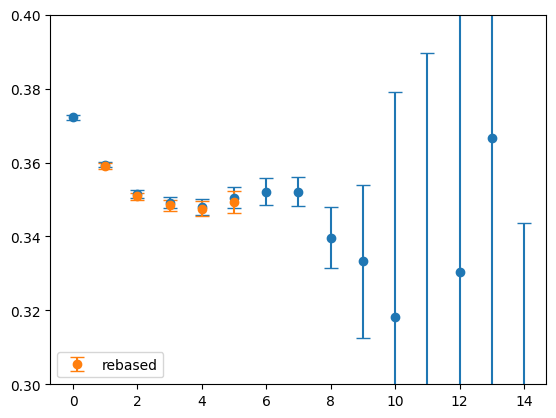

In [65]:
import matplotlib.pyplot as plt

print(cor_list[0])

plt.errorbar(*cor_list[0].plotInputs(), marker="o", capsize=5, linestyle='')
plt.errorbar(*cor_list2[0].plotInputs(), marker="o", capsize=5, linestyle='', label = "rebased")
plt.ylim(0.3,0.4)
plt.legend()

In [26]:
import numpy as np
import scipy as sp
import copy

def Correlation_Matrix(data: np.ndarray, t_0: int, t_1: int):
    """
    Produces the Matrix of Correlators of distribution type at given t_0 and t_1
    """

    data = np.array(data, dtype=object)

    shape_cor = np.shape(data)

    Cor_t_0 = np.empty(shape_cor, dtype=object)
    Cor_t_1 = np.empty(shape_cor, dtype=object)
    Cor_t_1plus1 = np.empty(shape_cor, dtype=object)

    for i, j in np.ndindex(shape_cor):
        if i >= j:
            Cor_t_0[i, j] = data[j, i].value(t_0)
            Cor_t_1[i, j] = data[j, i].value(t_1)
            Cor_t_1plus1[i, j] = data[j, i].value(t_1 + 1)
        else:
            Cor_t_0[i, j] = data[i, j].value(t_0)
            Cor_t_1[i, j] = data[i, j].value(t_1)
            Cor_t_1plus1[i, j] = data[i, j].value(t_1 + 1)

    return Cor_t_0, Cor_t_1, Cor_t_1plus1


def sampler(A):
    A = np.array(A, dtype=object)

    A_shape = np.shape(A)
    template = np.shape(A[0][0].unpack())

    A_out = np.empty(A_shape + template)

    for idx in np.ndindex(A_shape):
        A_out[idx] = A[idx].unpack()

    # Move matrix indices to the last two axes
    A_full = np.moveaxis(A_out, (0, 1), (-2, -1))

    return A_full


def g_eigh(A, B, rebase=False):
    if rebase == False:
        A_new = sampler(A)
        B_new = sampler(B)
    else:
        A_new = A
        B_new = B

    inner_shape = A_new.shape[:-2]
    outer_shape = (A_new.shape[-1],)

    eigen_vals = np.empty(inner_shape + outer_shape)
    eigen_vecs = np.empty(inner_shape + outer_shape + outer_shape)

    eigen_vals.fill(np.nan)
    eigen_vecs.fill(np.nan)

    for idx in np.ndindex(inner_shape):
        C_0 = A_new[idx]
        C_1 = B_new[idx]

        try:
            # Solves C_1 v = lambda C_0 v
            evals, evecs = sp.linalg.eigh(C_1, C_0)

            sort_v = np.argsort(-evals)

            eigen_vals[idx] = evals[sort_v]

            # IMPORTANT:
            # scipy.linalg.eigh returns eigenvectors as columns.
            # So sort columns, not rows.
            eigen_vecs[idx] = evecs[:, sort_v]

        except:
            eigen_vals.fill(np.nan)
            eigen_vecs.fill(np.nan)
            # Leave this sample as nan, continue with the rest
            return eigen_vals, eigen_vecs

    return eigen_vals, eigen_vecs


def effective_energy(eig_t0, eig_t1, dat_type):
    inner_shape = eig_t0.shape[:-1]
    outer_shape = eig_t0.shape[-1]

    eff_result = [copy.deepcopy(dat_type) for j in range(outer_shape)]

    for idx in np.ndindex(inner_shape):
        for i in range(outer_shape):
            val = eig_t0[idx][i] / eig_t1[idx][i]

            if val > 0 and np.isfinite(val):
                eff_result[i][idx] = np.log(val)
            else:
                eff_result[i][idx] = np.nan

    return eff_result


def rebasing(eigen_vec, Mat, n_keep=1):
    """
    Projects Mat into the subspace spanned by the first n_keep GEVP eigenvectors.

    eigen_vec has shape:
        jackknife_shape + (N, N)

    Mat is the original object-valued correlator matrix.
    """

    inner_shape = eigen_vec.shape[:-2]

    Mat2 = sampler(Mat)

    # Keep first n_keep eigenvectors.
    # Since eigenvectors are columns, this keeps columns 0, ..., n_keep - 1.
    vec = eigen_vec[..., :, :n_keep]

    proj_shape = inner_shape + (n_keep, n_keep)
    proj_mat = np.empty(proj_shape)

    for idx in np.ndindex(inner_shape):
        V = vec[idx]
        M = Mat2[idx]

        proj_mat[idx] = np.conjugate(V).T @ M @ V

    return proj_mat


def GEVP_exec(data, t_0, t_1):
    """
    No rebasing.
    """

    C0, C1, C2 = Correlation_Matrix(data, t_0, t_1)

    eig_t0_t1 = g_eigh(C0, C1)[0]
    eig_t0_t1plus1 = g_eigh(C0, C2)[0]

    eff_energy = effective_energy(
        eig_t0_t1,
        eig_t0_t1plus1,
        C0[0][0]
    )

    return eff_energy


def GEVP_exec_rebased(data, t_0, t_1, n_keep=2):
    """
    With rebasing.
    """

    C0, C1, C2 = Correlation_Matrix(data, t_0, t_1)

    eig_vec_t0_t1 = g_eigh(C0, C1)[1]

    C0_r = rebasing(eig_vec_t0_t1, C0, n_keep=n_keep)
    C1_r = rebasing(eig_vec_t0_t1, C1, n_keep=n_keep)
    C2_r = rebasing(eig_vec_t0_t1, C2, n_keep=n_keep)

    eig_t0_t1_r = g_eigh(C0_r, C1_r, rebase=True)[0]
    eig_t0_t1plus1_r = g_eigh(C0_r, C2_r, rebase=True)[0]

    eff_energy = effective_energy(
        eig_t0_t1_r,
        eig_t0_t1plus1_r,
        C0[0][0]
    )

    return eff_energy

In [29]:
E_n = [0, 1]

t_max = 15
Dt = 2

# Number of rebased states to keep



if not isinstance(E_n, int):

    Cor_List = np.empty(len(E_n), dtype=object)
    Cor_List_Rebased = np.empty(len(E_n), dtype=object)

    for idx in range(len(E_n)):

        data_no_rebase = sl.CorrelationFunction(t_max)
        data_rebased = sl.CorrelationFunction(t_max)

        for t0 in range(0, t_max):
            t = t0 + Dt

            data_no_rebase.setValue(t0, GEVP_exec(jdata_cors, t0, t)[E_n[idx]])
            data_no_rebase.setCoord(t0, float(t0))

            data_rebased.setValue(t0, GEVP_exec_rebased(jdata_cors, t0, t)[E_n[idx]])
            data_rebased.setCoord(t0, float(t0))

        Cor_List[idx] = data_no_rebase
        Cor_List_Rebased[idx] = data_rebased


else:

    Cor_List = sl.CorrelationFunction(t_max)
    Cor_List_Rebased = sl.CorrelationFunction(t_max)

    for t0 in range(0, t_max):
        t = t0 + Dt

        Cor_List.setValue(t0, GEVP_exec(jdata_cors, t0, t)[E_n])
        Cor_List.setCoord(t0, float(t0))

        Cor_List_Rebased.setValue(t0, GEVP_exec_rebased(jdata_cors, t0, t, n_keep=n_keep)[E_n])
        Cor_List_Rebased.setCoord(t0, float(t0))

0.0 : 0.422924 +- 0.002361
1.0 : 0.385224 +- 0.002044
2.0 : 0.373057 +- 0.003268
3.0 : 0.370193 +- 0.005185
4.0 : 0.366388 +- 0.008082
5.0 : 0.368653 +- 0.008826
6.0 : nan +- nan
7.0 : nan +- nan
8.0 : nan +- nan
9.0 : nan +- nan
10.0 : nan +- nan
11.0 : nan +- nan
12.0 : nan +- nan
13.0 : nan +- nan
14.0 : nan +- nan



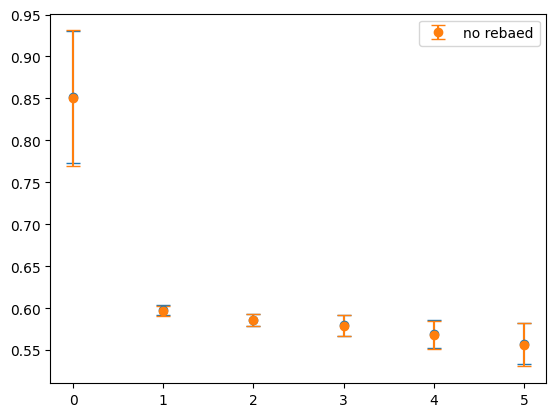

In [30]:
import matplotlib.pyplot as plt

print(cor_list[0])

plt.errorbar(*Cor_List_Rebased[1].plotInputs(), marker="o", capsize=5, linestyle='')
plt.errorbar(*Cor_List[1].plotInputs(), marker="o", capsize=5, linestyle='', label = "no rebaed")

plt.legend()

In [7]:
jdata_cors_no_sigma = [[jdata_cors[0][0],jdata_cors[0][1]],[jdata_cors[0][1],jdata_cors[1][1]]]
jdata_cors_no_pipiEx = [[jdata_cors[0][0],jdata_cors[0][2]],[jdata_cors[0][2],jdata_cors[2][2]]]
jdata_cors_pipi_111 = [[jdata_cors[0][0]]]


alpha = 1
beta = 1
gamma = 1

coeffs = [alpha, beta, gamma]
#print(type(jdata_cors[1][0]))

#jdata_cors

for i in range(3):
    for j in range(i,3):
        #print(i,j)
        jdata_cors[i][j] = jdata_cors[i][j]*coeffs[i]*coeffs[j]

In [7]:
def gevp_output(input_data, E_n, t_max, Dt, rebasing = False, rebased_time_slice = 1, rebased_Dt = 2):
    #time_array = np.arange(0, t_max)
    data = sl.CorrelationFunction(t_max)
    if rebasing == False:
        gevp_obj = sl.GEVP_OG(input_data)
        for t0 in range(0,t_max):
                t = t0 + Dt
                data.setValue(t0, gevp_obj.run(t0,t)[E_n])
                data.setCoord(t0, float(t0))
        return  data
    if rebasing == True:
        gevp_obj = sl.GEVP(input_data)
        for t0 in range(0,t_max):
            t = t0 + Dt
            data.setValue(t0, gevp_obj.run(t0,t, rebased_time_slice, rebased_time_slice + 
                                            rebased_Dt)[E_n])
            data.setCoord(t0, float(t0))
        return data

In [8]:


def gevp_output2(input_data, E_n, t_max, Dt, rebasing = False, rebased_time_slice = 1, rebased_Dt = 2):
    #time_array = np.arange(0, t_max)
    data = sl.CorrelationFunction(t_max)
    if rebasing == False:
        gevp_obj = sl.GEVP_bd(input_data)
        for t0 in range(0,t_max-1):
                t = t0 + Dt
                data.setValue(t0, gevp_obj.run(t0,t, rebase = False)[E_n])
                data.setCoord(t0, float(t0))
        return  data
    if rebasing == True:
        gevp_obj = sl.GEVP_bd(input_data)
        for t0 in range(0,t_max):
                t = t0 + Dt
                data.setValue(t0, gevp_obj.run(t0,t, rebased_time_slice, rebased_time_slice + 
                                                rebased_Dt)[E_n])
                data.setCoord(t0, float(t0))
        return data

<h1>Changing Rebasing Spacing (dt)</h1>

In [9]:
gevp_vals = []

results = []
indices = []

for i in range(2,12,2):
     gevp_data = (gevp_output2(bdjdata_cors, 0, 15, 2, rebasing=True, rebased_Dt= i, rebased_time_slice=2))
     gevp_data_nonBD= gevp_output(jdata_cors, 0, 15, 2, rebasing=True, rebased_Dt= i, rebased_time_slice=2)

     t_range = (3,9)

     N = gevp_data.value(2).size()
     print(N)

     fitfunc = sl.FitConstant()

     fitter = sl.Fitter(fitfunc)

     dd_test = gevp_data.sliceRange(*t_range)

     fitter.generateCovarianceMatrix(dd_test)

     jack_inrange = gevp_data_nonBD.sliceRange(*t_range)

     params = [sl.JackknifeDistribution(N, 0.38)]
     chisq, dof = fitter.fit(params, jack_inrange)
     print(params[0], chisq/float(dof))

     fit_y = sl.evaluateFitFunc(fitfunc,jack_inrange,params)
     plot_data = jack_inrange.plotInputs()
     plot_result = fit_y.plotInputs()   
     pyplot.errorbar(plot_data[0],plot_data[1],yerr=plot_data[2])

     results.append(f"{plot_result[1][0]} + \pm + {plot_result[2][0]}")
     indices.append(i)

data_array_test_1 = [indices, results]

print(data_array_test_1)

#plot the fitted energy over the rebased_Dt
#plot for t_range (5,9)
#plot for 3x3 gevp to show systematics, know where it breaks down such that it motivates the rebasing step, then do 2x2 (rebasing may not give much, as sanity check used toy model and then  give overview of behaviour)



/Users/clementcharles/Documents/PySARLaC/src/PySaRLAC/GEVP.py:803: ComplexWarning: Casting complex values to real discards the imaginary part
  eigen_values[k][i] = eigvals[idx]
/Users/clementcharles/Documents/PySARLaC/src/PySaRLAC/GEVP.py:786: ComplexWarning: Casting complex values to real discards the imaginary part
  eigen_values[k][i] = eigvals[idx2]


KeyboardInterrupt: 

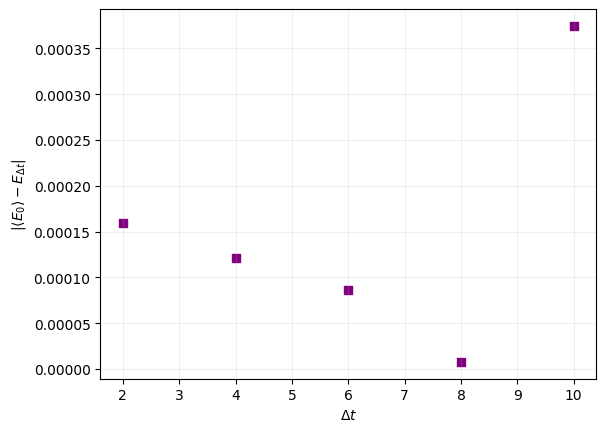

In [33]:
import matplotlib.pyplot as plt

E0_energies = []

for val in data_array_test_1[1]:
    E0_energies.append(float(val[0:18]))

mean_E0_for_Dt_var = np.mean(E0_energies)

E0_shift = np.abs(mean_E0_for_Dt_var - np.array(E0_energies))

plt.scatter(data_array_test_1[0], E0_shift, marker = 's', color = "purple")
plt.grid(alpha=0.2)
plt.xlabel(r"$\Delta t$")
plt.ylabel(r"$|\langle E_0 \rangle - E_{\Delta t}|$")
plt.show()

[92, 728]
[92, 728]
[92, 728]
[92, 728]
[92, 728]
[92, 728]
[92, 728]
[92, 728]
[92, 728]
[92, 728]
[92, 728]
[92, 728]
[92, 728]
[92, 728]
[92, 728]


/Users/clementcharles/Documents/PySARLaC/src/PySaRLAC/GEVP.py:100: ComplexWarning: Casting complex values to real discards the imaginary part
  eigen_values[i] = eigvals[idx2]


92
Performing a fit with 1 free parameters and 6 degrees of freedom
0.348849 +- 0.001101 2.074167 +- 1.317002
[92, 728]
[92, 728]
[92, 728]
[92, 728]
[92, 728]
[92, 728]
[92, 728]
[92, 728]
[92, 728]
[92, 728]
[92, 728]
[92, 728]
[92, 728]
[92, 728]
[92, 728]
92
Performing a fit with 1 free parameters and 6 degrees of freedom
0.348925 +- 0.001081 2.425970 +- 1.447524
[92, 728]
[92, 728]
[92, 728]
[92, 728]
[92, 728]
[92, 728]
[92, 728]
[92, 728]
[92, 728]
[92, 728]
[92, 728]
[92, 728]
[92, 728]


KeyboardInterrupt: 

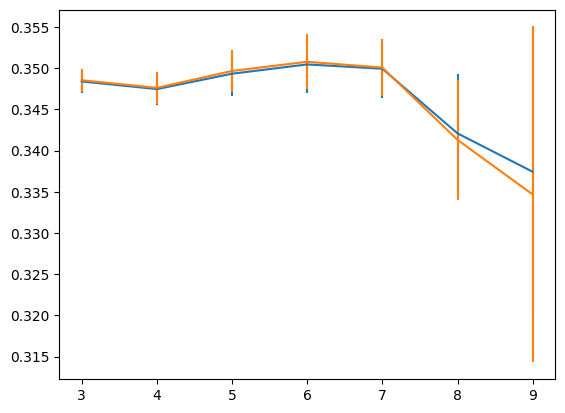

In [10]:
gevp_vals = []

results = []
indices = []

for i in range(2,12,2):
     gevp_data = (gevp_output2(bdjdata_cors, 0, 15, 2, rebasing=True, rebased_Dt= 8, rebased_time_slice=i))
     gevp_data_nonBD= gevp_output(jdata_cors, 0, 15, 2, rebasing=True, rebased_Dt= 8, rebased_time_slice=i)

     t_range = (3,9)

     N = gevp_data.value(2).size()
     print(N)

     fitfunc = sl.FitConstant()

     fitter = sl.Fitter(fitfunc)

     dd_test = gevp_data.sliceRange(*t_range)

     fitter.generateCovarianceMatrix(dd_test)

     jack_inrange = gevp_data_nonBD.sliceRange(*t_range)

     params = [sl.JackknifeDistribution(N, 0.38)]
     chisq, dof = fitter.fit(params, jack_inrange)
     print(params[0], chisq/float(dof))

     fit_y = sl.evaluateFitFunc(fitfunc,jack_inrange,params)
     plot_data = jack_inrange.plotInputs()
     plot_result = fit_y.plotInputs()   
     pyplot.errorbar(plot_data[0],plot_data[1],yerr=plot_data[2])

     results.append(f"{plot_result[1][0]} + \pm + {plot_result[2][0]}")
     indices.append(i)

data_array_test_1 = [indices, results]

print(data_array_test_1)

#plot the fitted energy over the rebased_Dt
#plot for t_range (5,9)
#plot for 3x3 gevp to show systematics, know where it breaks down such that it motivates the rebasing step, then do 2x2 (rebasing may not give much, as sanity check used toy model and then  give overview of behaviour)



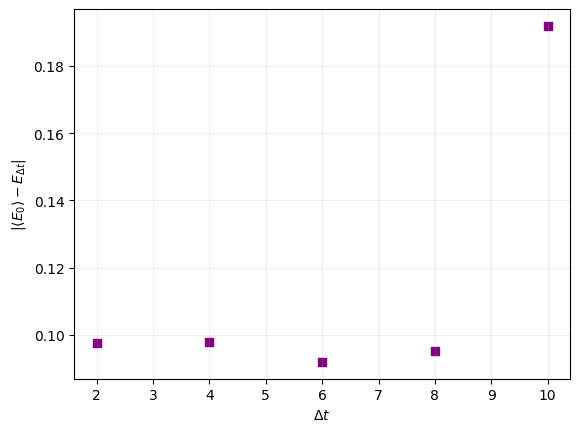

In [35]:
import matplotlib.pyplot as plt

E0_energies = []

for val in data_array_test_1[1]:
    E0_energies.append(float(val[0:18]))

mean_E0_for_Dt_var = np.mean(E0_energies)

E0_shift = np.abs(mean_E0_for_Dt_var - np.array(E0_energies))

plt.scatter(data_array_test_1[0], E0_shift, marker = 's', color = "purple")
plt.grid(alpha=0.2)
plt.xlabel(r"$\Delta t$")
plt.ylabel(r"$|\langle E_0 \rangle - E_{\Delta t}|$")
plt.show()

[92, 728]
[92, 728]
[92, 728]
[92, 728]
[92, 728]
[92, 728]
[92, 728]
92
Performing a fit with 1 free parameters and 3 degrees of freedom
0.354164 +- 0.001557 5.104172 +- 4.361467
[92, 728]
[92, 728]
[92, 728]
[92, 728]
[92, 728]
[92, 728]
[92, 728]
92
Performing a fit with 1 free parameters and 3 degrees of freedom
0.349950 +- 0.002600 3.585860 +- 6.723228
[[1, 2], ['0.35416362011804875 + \\pm + 0.001557258484336602', '0.34995028694680896 + \\pm + 0.0025995489434457683']]


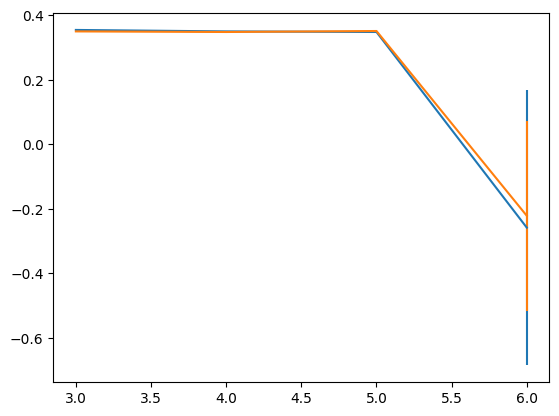

In [11]:
gevp_vals = []

results = []
indices = []

for i in range(1,3):
     gevp_data = (gevp_output2(bdjdata_cors, 0, 7, i, rebasing=True, rebased_Dt= 8, rebased_time_slice=6))
     gevp_data_nonBD= gevp_output(jdata_cors, 0, 7, i, rebasing=True, rebased_Dt= 8, rebased_time_slice=6)

     t_range = (3,6)

     N = gevp_data.value(2).size()
     print(N)

     fitfunc = sl.FitConstant()

     fitter = sl.Fitter(fitfunc)

     dd_test = gevp_data.sliceRange(*t_range)

     fitter.generateCovarianceMatrix(dd_test)

     jack_inrange = gevp_data_nonBD.sliceRange(*t_range)

     jack_sub = jack_inrange - jack_inrange.value(0)

     #print(diff)

     params = [sl.JackknifeDistribution(N, 0.38)]
     chisq, dof = fitter.fit(params, jack_inrange)
     print(params[0], chisq/float(dof))

     fit_y = sl.evaluateFitFunc(fitfunc,jack_inrange,params)
     plot_data = jack_inrange.plotInputs()
     plot_result = fit_y.plotInputs()   
     pyplot.errorbar(plot_data[0],plot_data[1],yerr=plot_data[2])

     results.append(f"{plot_result[1][0]} + \pm + {plot_result[2][0]}")
     indices.append(i)

data_array_test_1 = [indices, results]

print(data_array_test_1)

#plot the fitted energy over the rebased_Dt
#plot for t_range (5,9)
#plot for 3x3 gevp to show systematics, know where it breaks down such that it motivates the rebasing step, then do 2x2 (rebasing may not give much, as sanity check used toy model and then  give overview of behaviour)



In [12]:
gevp_data = (gevp_output2(bdjdata_cors, 0, 7, 2, rebasing=True, rebased_Dt= 2, rebased_time_slice=2))
gevp_data_nonBD= gevp_output(jdata_cors, 0, 7, 2, rebasing=True, rebased_Dt= 2, rebased_time_slice=2)

[92, 728]
[92, 728]
[92, 728]
[92, 728]
[92, 728]
[92, 728]
[92, 728]


0.0 : <PySaRLAC.BlockDoubleJackknifeDistribution.BlockDoubleJackknifeDistribution object at 0x141c96220>
1.0 : <PySaRLAC.BlockDoubleJackknifeDistribution.BlockDoubleJackknifeDistribution object at 0x141d4d5b0>
2.0 : <PySaRLAC.BlockDoubleJackknifeDistribution.BlockDoubleJackknifeDistribution object at 0x141d50910>
3.0 : <PySaRLAC.BlockDoubleJackknifeDistribution.BlockDoubleJackknifeDistribution object at 0x141d508e0>
4.0 : <PySaRLAC.BlockDoubleJackknifeDistribution.BlockDoubleJackknifeDistribution object at 0x141c7a610>
5.0 : <PySaRLAC.BlockDoubleJackknifeDistribution.BlockDoubleJackknifeDistribution object at 0x141d50970>
6.0 : <PySaRLAC.BlockDoubleJackknifeDistribution.BlockDoubleJackknifeDistribution object at 0x141d5cfa0>



<ErrorbarContainer object of 3 artists>

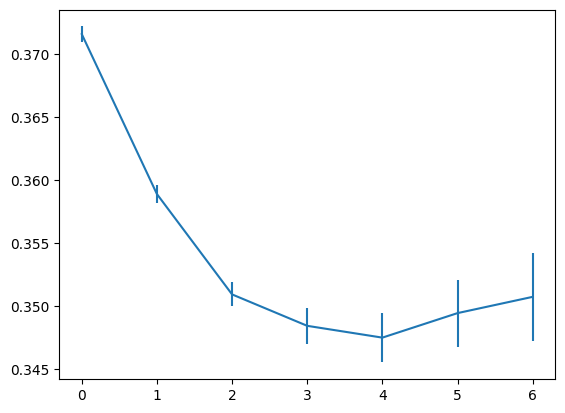

In [13]:
print(gevp_data)
plot = gevp_data_nonBD.plotInputs()
pyplot.errorbar(plot[0],plot[1], yerr=plot[2])

92
Performing a fit with 1 free parameters and 3 degrees of freedom
0.348925 +- 0.001201 0.784226 +- 1.168387


<ErrorbarContainer object of 3 artists>

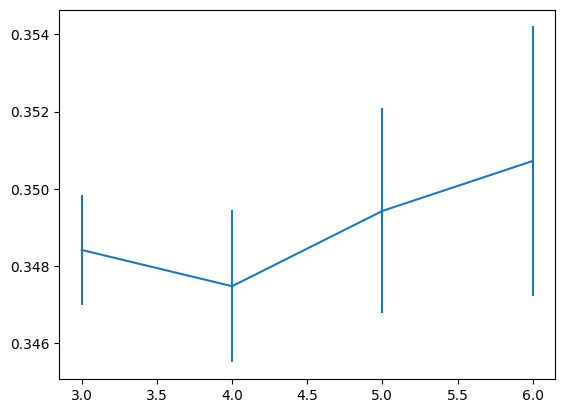

In [52]:
t_range = (3,6)

N = gevp_data.value(2).size()
print(N)

fitfunc = sl.FitConstant()

fitter = sl.Fitter(fitfunc)

dd_test = gevp_data.sliceRange(*t_range)

fitter.generateCovarianceMatrix(dd_test)

jack_inrange = gevp_data_nonBD.sliceRange(*t_range)

jack_sub = jack_inrange - jack_inrange.value(0)

#print(diff)

params = [sl.JackknifeDistribution(N, 0.38)]
chisq, dof = fitter.fit(params, jack_inrange)
print(params[0], chisq/float(dof))

fit_y = sl.evaluateFitFunc(fitfunc,jack_inrange,params)
plot_data = jack_inrange.plotInputs()
plot_result = fit_y.plotInputs()   
pyplot.errorbar(plot_data[0],plot_data[1],yerr=plot_data[2])

In [54]:
params_list = []
for t_start in range(0,6):
    t_range = (t_start,6)

    N = gevp_data.value(2).size()
    print(N)

    fitfunc = sl.FitConstant()

    fitter = sl.Fitter(fitfunc)

    dd_test = gevp_data.sliceRange(*t_range)

    fitter.generateCovarianceMatrix(dd_test)

    jack_inrange = gevp_data_nonBD.sliceRange(*t_range)

    #jack_sub = jack_inrange - jack_inrange.value(0)



    #print(diff)

    params = [sl.JackknifeDistribution(N, 0.38)]
    chisq, dof = fitter.fit(params, jack_inrange)
    print(params[0], chisq/float(dof), f"time slice {t_start}")
    params_list.append(params[0])
    

    #fit_y = sl.evaluateFitFunc(fitfunc,jack_inrange,params)
    #plot_data = jack_inrange.plotInputs()
    #plot_result = fit_y.plotInputs()   
    #pyplot.errorbar(plot_data[0],plot_data[1],yerr=plot_data[2])



92
Performing a fit with 1 free parameters and 6 degrees of freedom
0.363653 +- 0.000557 105.379253 +- 10.454933 time slice 0
92
Performing a fit with 1 free parameters and 5 degrees of freedom
0.356455 +- 0.000512 19.916395 +- 3.952737 time slice 1
92
Performing a fit with 1 free parameters and 4 degrees of freedom
0.351063 +- 0.000787 2.336172 +- 1.729139 time slice 2
92
Performing a fit with 1 free parameters and 3 degrees of freedom
0.348925 +- 0.001201 0.784226 +- 1.168387 time slice 3
92
Performing a fit with 1 free parameters and 2 degrees of freedom
0.347930 +- 0.001967 0.845741 +- 1.801129 time slice 4
92
Performing a fit with 1 free parameters and 1 degrees of freedom
0.349624 +- 0.002743 0.423114 +- 1.625154 time slice 5


6


<ErrorbarContainer object of 3 artists>

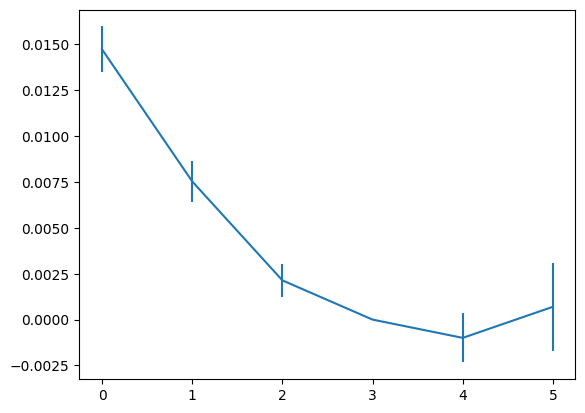

In [55]:
import matplotlib.pyplot as plt 
t_start_vals = [i for i  in range(0,6)]
params_sub = [ j - params_list[3] for j in params_list ]
params_means = [ j.mean() for j in params_sub]

print(len(params_means))
params_errors = [ j.standardError() for j in params_sub ]
plt.errorbar(t_start_vals, params_means, yerr=params_errors)

In [ ]:
params_list = []
for t_start in range(0,6):
    t_range = (t_start,6)

    N = gevp_data.value(2).size()
    print(N)

    fitfunc = sl.FitConstant()

    fitter = sl.Fitter(fitfunc)

    dd_test = gevp_data.sliceRange(*t_range)

    

    jack_inrange = gevp_data_nonBD.sliceRange(*t_range)

    fitter.generateCovarianceMatrix(jack_inrange)
    #print(np.shape(fitter.cov))
    N_cols = np.shape(fitter.cov)[0]
    cov_boosted = np.zeros((N_cols,N_cols,N))
    for t1 in range(N_cols):
        for t2 in range(N_cols):
            for s in range(N):
                cov_boosted[t1,t2,s] = fitter.cov[t1][t2]
    #jack_sub = jack_inrange - jack_inrange.value(0)

    fitter.cov = cov_boosted


    #print(diff)

    params = [sl.JackknifeDistribution(N, 0.38)]
    chisq, dof = fitter.fit(params, jack_inrange)
    print(params[0], chisq/float(dof), f"time slice {t_start}")
    params_list.append(params[0])
    

    #fit_y = sl.evaluateFitFunc(fitfunc,jack_inrange,params)
    #plot_data = jack_inrange.plotInputs()
    #plot_result = fit_y.plotInputs()   
    #pyplot.errorbar(plot_data[0],plot_data[1],yerr=plot_data[2])



92
Performing a fit with 1 free parameters and 6 degrees of freedom
0.363118 +- 0.000448 100.024884 +- 8.163359 time slice 0
92
Performing a fit with 1 free parameters and 5 degrees of freedom
0.357157 +- 0.000522 21.279577 +- 4.122420 time slice 1
92
Performing a fit with 1 free parameters and 4 degrees of freedom
0.351279 +- 0.000787 1.674759 +- 1.308335 time slice 2
92
Performing a fit with 1 free parameters and 3 degrees of freedom
0.349342 +- 0.001196 0.685487 +- 0.949609 time slice 3
92
Performing a fit with 1 free parameters and 2 degrees of freedom
0.347891 +- 0.001904 0.542829 +- 1.042475 time slice 4
92
Performing a fit with 1 free parameters and 1 degrees of freedom
0.349523 +- 0.002650 0.290204 +- 1.071396 time slice 5


6


<ErrorbarContainer object of 3 artists>

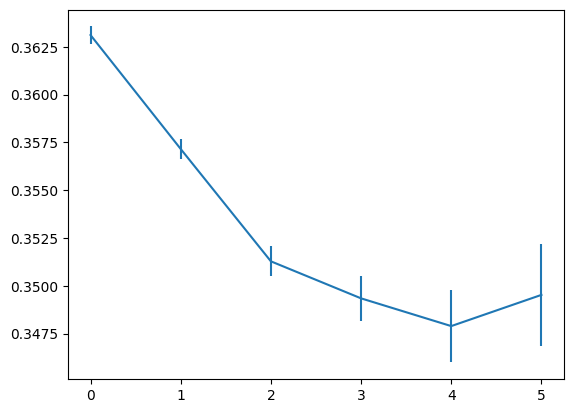

In [41]:
import matplotlib.pyplot as plt 
t_start_vals = [i for i  in range(0,6)]
params_means = [ j.mean() for j in params_list ]
print(len(params_means))
params_errors = [ j.standardError() for j in params_list ]
plt.errorbar(t_start_vals, params_means, yerr=params_errors)

6


<ErrorbarContainer object of 3 artists>

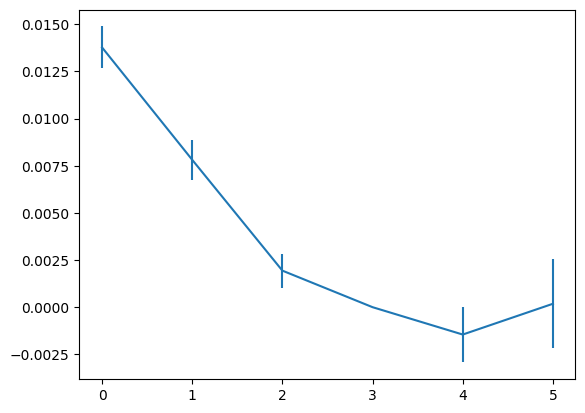

In [44]:
import matplotlib.pyplot as plt 
t_start_vals = [i for i  in range(0,6)]
params_sub = [ j - params_list[3] for j in params_list ]
params_means = [ j.mean() for j in params_sub]

print(len(params_means))
params_errors = [ j.standardError() for j in params_sub ]
plt.errorbar(t_start_vals, params_means, yerr=params_errors)

<ErrorbarContainer object of 3 artists>

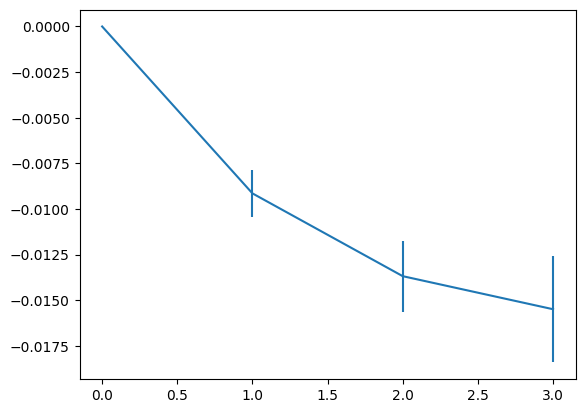

In [11]:
import matplotlib.pyplot as plt

plot = jack_sub.plotInputs()
pyplot.errorbar(plot[0],plot[1], yerr=plot[2])

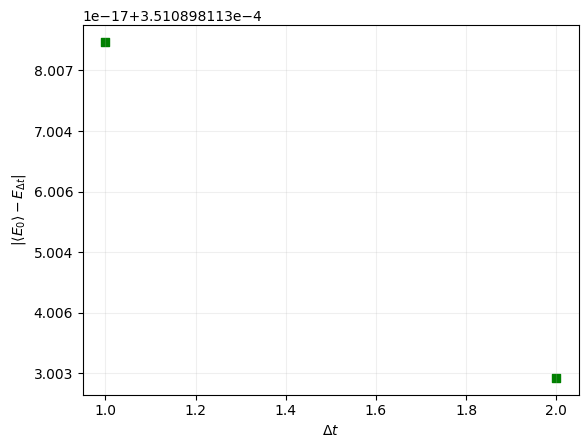

In [39]:
import matplotlib.pyplot as plt

E0_energies = []

for val in data_array_test_1[1]:
    E0_energies.append(float(val[0:18]))

mean_E0_for_Dt_var = np.mean(E0_energies)

E0_shift = np.abs(mean_E0_for_Dt_var - np.array(E0_energies))

plt.scatter(data_array_test_1[0], E0_shift, marker = 's', color = "green")
plt.grid(alpha=0.2)
plt.xlabel(r"$\Delta t$")
plt.ylabel(r"$|\langle E_0 \rangle - E_{\Delta t}|$")
plt.show()

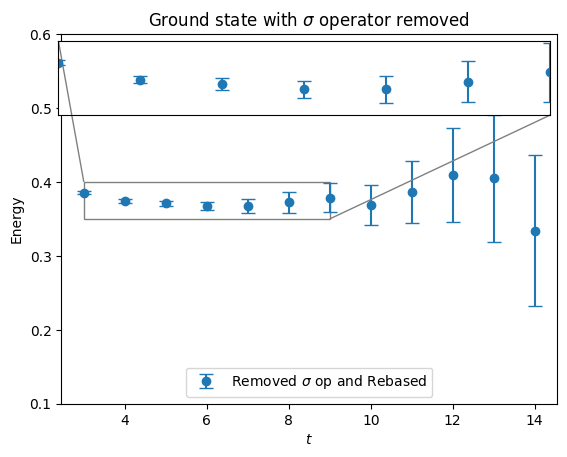

In [12]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes, mark_inset

fig, ax = plt.subplots()

#gevp_without_sigma = gevp_output(jdata_cors_no_sigma, 0, 15, 3)

gevp_without_sigma_rebased = gevp_output(jdata_cors_no_sigma, 0, 15, 3, rebasing=True)


#ax.errorbar(*gevp_without_sigma.plotInputs(), label = r"Removed $\sigma$ op", marker="o", capsize=5, linestyle='')
ax.errorbar(*gevp_without_sigma_rebased.plotInputs(), label = r"Removed $\sigma$ op and Rebased", marker="o", capsize=5, linestyle='')

x1, x2, y1, y2 = 3, 9, 0.35, 0.4
axins = zoomed_inset_axes(ax, zoom=2, loc='upper right')
#axins.errorbar(gevp_without_sigma.plotInputs()[0]+0.1, *gevp_without_sigma.plotInputs()[1:], marker="o", capsize=5, linestyle='')
axins.errorbar(*gevp_without_sigma_rebased.plotInputs(), marker="o", capsize=5, linestyle='')
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)

# Hide ticks inside inset
axins.set_xticks([])
axins.set_yticks([])

# Draw lines between inset and zoomed area
mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.5")

ax.set_title(r"Ground state with $\sigma$ operator removed")
ax.set_ylabel("Energy")
ax.set_xlabel(r"$t$")
ax.set_ylim(0.1, 0.6)
ax.legend(loc = "lower center")

<class 'PySaRLAC.CorrelationFunction.CorrelationFunction'>
[92, 728]
[92, 728]
[92, 728]
[92, 728]
[92, 728]
[92, 728]
[92, 728]


KeyboardInterrupt: 

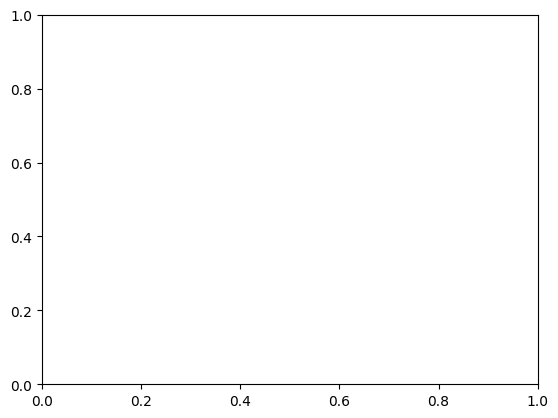

In [13]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes, mark_inset

fig, ax = plt.subplots()

print(type(bdjdata_cors[0][0]))

gevp_without_sigma_rebased2 = gevp_output2(bdjdata_cors, 0, 15, 2, rebasing=True, rebased_Dt= 4, rebased_time_slice=2)

gevp_without_sigma_rebased = gevp_output(jdata_cors, 0, 15, 2, rebasing=True, rebased_Dt= 4, rebased_time_slice=2)

ax.errorbar(*gevp_without_sigma_rebased.plotInputs()[:-1], label = r"3 by 3 GEVP Rebased", marker="o", capsize=5, linestyle='')

x1, x2, y1, y2 = 3, 9, 0.35, 0.4
axins = zoomed_inset_axes(ax, zoom=2, loc='upper right')
axins.errorbar(*gevp_without_sigma_rebased.plotInputs(), marker="o", capsize=5, linestyle='')
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)

# Hide ticks inside inset
axins.set_xticks([])
axins.set_yticks([])

# Draw lines between inset and zoomed area
mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.5")

ax.set_title(r"Ground state with $\sigma$ operator removed")
ax.set_ylabel("Energy")
ax.set_xlabel(r"$t$")
ax.set_ylim(0.1, 0.6)
ax.legend(loc = "lower center")

In [ ]:
t_range = (4,9)

N = gevp_without_sigma_rebased.value(2).size()

fitfunc = sl.FitConstant()

fitter = sl.Fitter(fitfunc)

dd_test = gevp_without_sigma_rebased2.sliceRange(*t_range)

fitter.generateCovarianceMatrix(dd_test)

jack_inrange = gevp_without_sigma_rebased.sliceRange(*t_range)

params = [sl.JackknifeDistribution(N, 0.38)]
chisq, dof = fitter.fit(params, jack_inrange)
print(params[0], chisq/float(dof))

#Compare results with frozen and unfrozen. Stat. result for unfrozen case should be slightly higher
#Look at the cov matrix itself. Substract on sample by sample basis. Plot in linear format all samples.
#look at tmin dependence, tabulate all result, and plots for excited state contamination


Performing a fit with 1 free parameters and 5 degrees of freedom
0.350895 +- 0.000793 2.119978 +- 1.372070


4.0 : 0.350907 +- 0.000952
5.0 : 0.348407 +- 0.001428
6.0 : 0.347474 +- 0.001969
7.0 : 0.349403 +- 0.002645
8.0 : 0.350647 +- 0.003457
9.0 : 0.350414 +- 0.003540



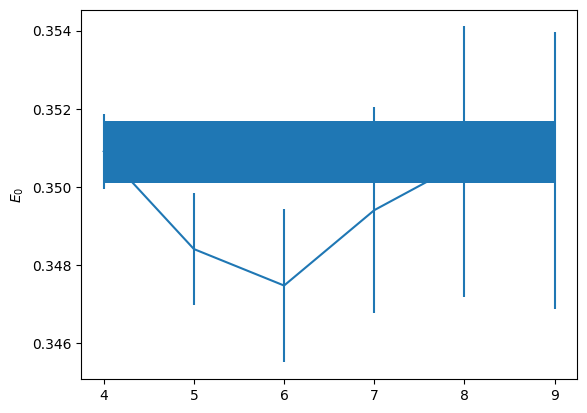

In [ ]:
fit_y = sl.evaluateFitFunc(fitfunc,jack_inrange,params)
plot_data = jack_inrange.plotInputs()
plot_result = fit_y.plotInputs()
#print(rf"E_{energy_state}:  {plot_result[1][0]} +/- {plot_data[2][0]}")

print(jack_inrange)
pyplot.errorbar(plot_data[0],plot_data[1],yerr=plot_data[2])
pyplot.fill_between(plot_result[0],plot_result[1]-plot_result[2],plot_result[1]+plot_result[2])
plt.ylabel(r"$E_0$")
plt.savefig("gevp_lattice_1.svg", format="svg", bbox_inches="tight")

In [ ]:
print(plot_result[1][0], "\pm", plot_result[2][0])

0.35089465894705774 \pm 0.0007933432268535527


In [ ]:
gevp_without_sigma_rebased2.value(3)[0]

/home/clemo556/Documents/PySARLaC/src/PySaRLAC/GEVP.py:278: ComplexWarning: Casting complex values to real discards the imaginary part
  eigen_values[i] = eigvals[idx]
/home/clemo556/Documents/PySARLaC/src/PySaRLAC/GEVP.py:264: ComplexWarning: Casting complex values to real discards the imaginary part
  eigen_values[i] = eigvals[idx2]


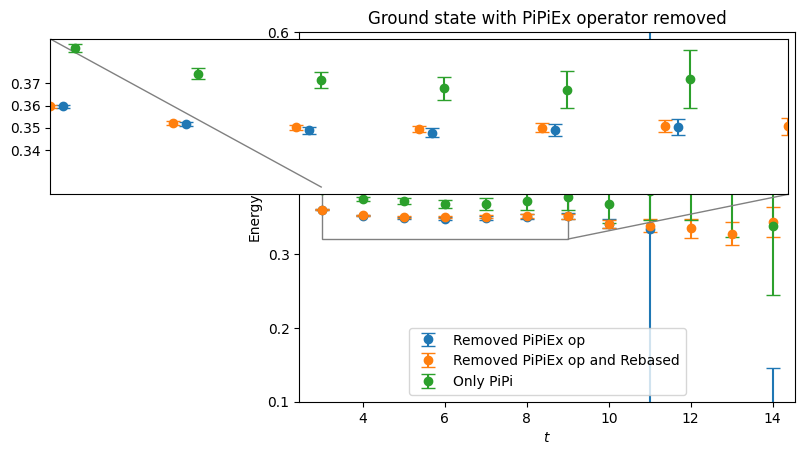

In [ ]:
gevp_without_pipiEx = gevp_output(jdata_cors_no_pipiEx, 0, 15, 3)

gevp_without_pipiEx_rebased = gevp_output(jdata_cors_no_pipiEx, 0, 15, 3, rebasing=True)

gevp_without_pipi_111 = gevp_output(jdata_cors_pipi_111, 0, 15, 3)

fig, ax = plt.subplots()


ax.errorbar(*gevp_without_pipiEx.plotInputs(), label = r"Removed PiPiEx op", marker="o", capsize=5, linestyle='')
ax.errorbar(*gevp_without_pipiEx_rebased.plotInputs(), label = r"Removed PiPiEx op and Rebased", marker="o", capsize=5, linestyle='')
ax.errorbar(*gevp_without_pipi_111.plotInputs(), label = r"Only PiPi", marker="o", capsize=5, linestyle='')

x1, x2, y1, y2 = 3, 9, 0.32, 0.39
axins = zoomed_inset_axes(ax, zoom=3, loc='upper right')
axins.errorbar(gevp_without_pipiEx.plotInputs()[0]+0.1, *gevp_without_pipiEx.plotInputs()[1:], marker="o", capsize=5, linestyle='')
axins.errorbar(*gevp_without_pipiEx_rebased.plotInputs(), marker="o", capsize=5, linestyle='')
axins.errorbar(gevp_without_pipi_111.plotInputs()[0]+0.2, *gevp_without_pipi_111.plotInputs()[1:], label = r"Only PiPi", marker="o", capsize=5, linestyle='')
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)
#axins.set_yticks()
# Hide ticks inside inset
axins.set_xticks([])
axins.set_yticks([0.34,0.35, 0.36, 0.37])

# Draw lines between inset and zoomed area
mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.5")

ax.set_title(r"Ground state with PiPiEx operator removed")
ax.set_ylabel("Energy")
ax.set_xlabel(r"$t$")
ax.set_ylim(0.1, 0.6)
ax.legend(loc = "lower center")

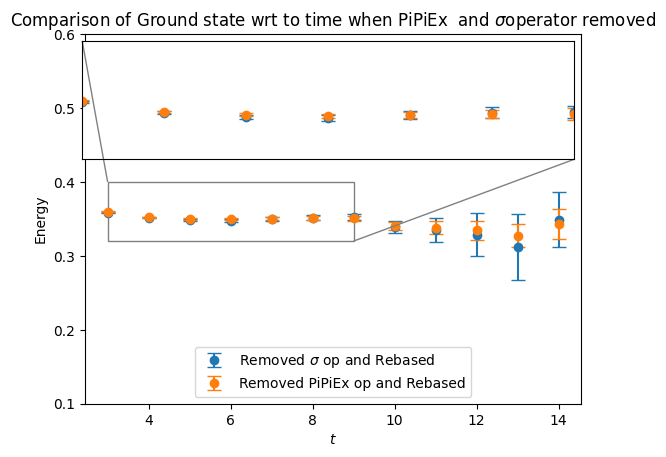

In [ ]:
fig, ax = plt.subplots()


ax.errorbar(*gevp_without_sigma_rebased.plotInputs(), label = r"Removed $\sigma$ op and Rebased", marker="o", capsize=5, linestyle='')
ax.errorbar(*gevp_without_pipiEx_rebased.plotInputs(), label = r"Removed PiPiEx op and Rebased", marker="o", capsize=5, linestyle='')

x1, x2, y1, y2 = 3, 9, 0.32, 0.4
axins = zoomed_inset_axes(ax, zoom=2, loc='upper right')
axins.errorbar(*gevp_without_sigma_rebased.plotInputs(), marker="o", capsize=5, linestyle='')
axins.errorbar(*gevp_without_pipiEx_rebased.plotInputs(), marker="o", capsize=5, linestyle='')
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)

# Hide ticks inside inset
axins.set_xticks([])
axins.set_yticks([])

# Draw lines between inset and zoomed area
mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.5")

ax.set_title(r"Comparison of Ground state wrt to time when PiPiEx  and $\sigma $operator removed")
ax.set_ylabel("Energy")
ax.set_xlabel(r"$t$")
ax.set_ylim(0.1, 0.6)
ax.legend(loc = "lower center")

/home/clemo556/Documents/PySARLaC/src/PySaRLAC/GEVP.py:265: ComplexWarning: Casting complex values to real discards the imaginary part
  eigen_vectors[i] = eigvecs[:,idx2]


Rebasing


(-0.3, 0.4)

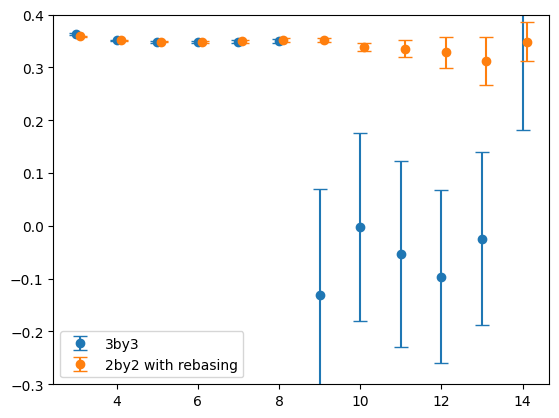

In [ ]:
gevp_3by3 = gevp_output(jdata_cors, 0, 15, 3)
print("Rebasing")
gevp_3by3_rebased = gevp_output(jdata_cors, 0, 15, 3, rebasing=True)


fig, ax = plt.subplots()


ax.errorbar(*gevp_3by3.plotInputs(), label = r"3by3", marker="o", capsize=5, linestyle='')
ax.errorbar(gevp_3by3_rebased.plotInputs()[0]+0.1, *gevp_3by3_rebased.plotInputs()[1:], label = r"2by2 with rebasing", marker="o", capsize=5, linestyle='')
ax.legend()
ax.set_ylim(-0.3, 0.4)

#make a protection code, determine what values where I get error, disregard these point in jackknife, label these points (log(-#))


Rebasing


(0.0, 1.0)

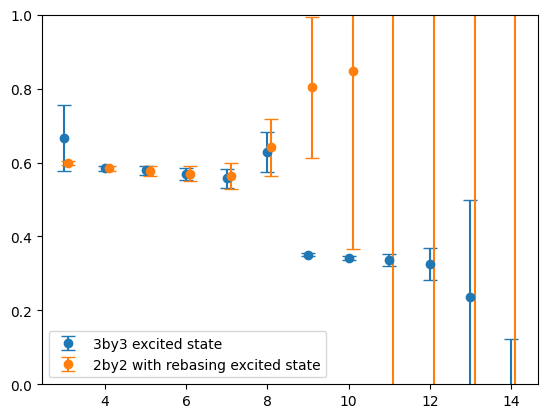

In [ ]:
gevp_3by3_Ex = gevp_output(jdata_cors, 1, 15, 3)
print("Rebasing")
gevp_3by3_rebased_Ex = gevp_output(jdata_cors, 1, 15, 3, rebasing=True)


fig, ax = plt.subplots()


ax.errorbar(*gevp_3by3_Ex.plotInputs(), label = r"3by3 excited state", marker="o", capsize=5, linestyle='')
ax.errorbar(gevp_3by3_rebased_Ex.plotInputs()[0]+0.1, *gevp_3by3_rebased_Ex.plotInputs()[1:], label = r"2by2 with rebasing excited state", marker="o", capsize=5, linestyle='')
ax.legend()
ax.set_ylim(0, 1)


#if gevp fails then discard entire time-slice
#perform fits (Change rabased params st the orange curve error bar are similar to blue error bars)
#Write results up with all data thus far with various fits (similar to small research paper) ---> draw conclusions (prepare for monday meeting)
#Compare with 2020 results, use same t_min as paper (t_min=6), do 3by3 and 2by2 with rebasing

<h3>Running tests for variable rebased Dt and t0</h3>

(0.51, 0.68)

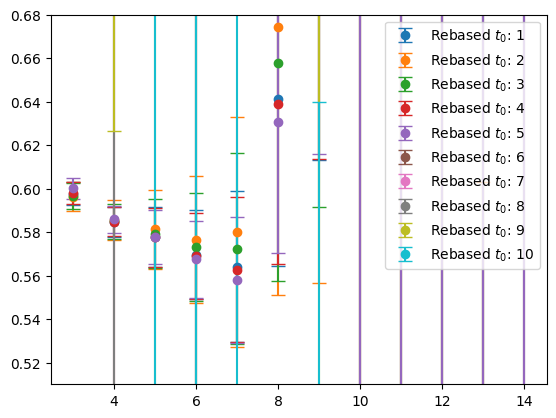

In [ ]:
N_rebased_slices = 10

rebased_GEVP_for_variable_timeslice =  np.empty(N_rebased_slices, dtype=sl.CorrelationFunction)

rebased_t0 = 1

for i in range(N_rebased_slices):
    
    rebased_GEVP_for_variable_timeslice[i] = gevp_output(jdata_cors, 1, 15, 3, rebased_time_slice = i + rebased_t0, rebasing = True)
    
fig, ax = plt.subplots()

for j in range(N_rebased_slices):
    ax.errorbar(*rebased_GEVP_for_variable_timeslice[j].plotInputs(), label = rf"Rebased $t_0$: {j + rebased_t0}", marker="o", capsize=5, linestyle='')
    
ax.legend()
ax.set_ylim(0.51, 0.68)

#create data without any noise, which has 5 states. 4 and 5 state used to mimic contamination
#Step 1: Create data set with only 3 states
#Step 2: Introduce Noise (Gaussian noise), amplitude of noise can increase as function of time
#Step 3: Called noise eps(t), data * (1+eps(t)), Create raw data by regenerating noise 100s, len(dataset)=100
#Step 4: Perform Jacknife, use code to analyze dataset, we should not have any systematic error, GEVP should give energy value consistent with real value (assigned) with some stat error
#Step 5: Use real value for state op coupling and the energy and vary the amplitude of eps (gradually increase error) so we should have log(-ve)
#Step 6: Introduce the 4th state. Figure out what is the coupling between the 4th state and 3 operator, vary the coupling (all large, coupling to ground large adn sig, piex small)
#First make sure 1-3 is completely align with expectations, then Move to 6
#Check if you gradual increase  error GEVP will fail then rebasing should extend GEVP then fail
#Reminder to implement protector code in GEVP object, jackknife method for resampling which help squeeeze data to central value, extra factor of (N-1) if wedont introduce this factor
#jckknife samples under estimate the error but for log(-ve) it introduce major error, more breakdown likely in bootstrap method

(0.51, 0.68)

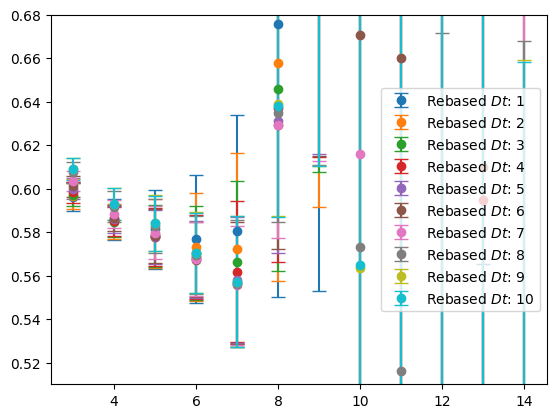

In [ ]:
N_rebased_Dt = 10

rebased_GEVP_for_variable_Dt=  np.empty(N_rebased_slices, dtype=sl.CorrelationFunction)

rebased_Dt0 = 1

for i in range(N_rebased_slices):
    
    rebased_GEVP_for_variable_Dt[i] = gevp_output(jdata_cors, 1, 15, 3, rebased_Dt = i + rebased_Dt0, rebased_time_slice = 3, rebasing = True)
    
fig, ax = plt.subplots()

for j in range(N_rebased_Dt):
    ax.errorbar(*rebased_GEVP_for_variable_Dt[j].plotInputs(), label = rf"Rebased $Dt$: {j + rebased_Dt0}", marker="o", capsize=5, linestyle='')
    
ax.legend()
ax.set_ylim(0.51, 0.68)

#jackknife diff between Dt=1

(0.51, 0.68)

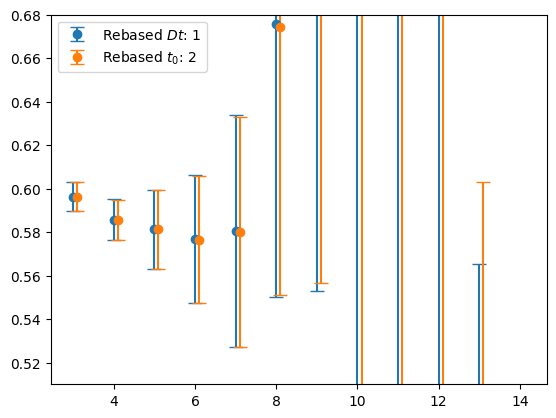

In [ ]:
fig, ax = plt.subplots()
ax.errorbar(*rebased_GEVP_for_variable_Dt[0].plotInputs(), label = rf"Rebased $Dt$: {0 + rebased_Dt0}", marker="o", capsize=5, linestyle='')
ax.errorbar(*rebased_GEVP_for_variable_timeslice[1].plotInputs(x_offset = 0.1), label = rf"Rebased $t_0$: {1 + rebased_t0}", marker="o", capsize=5, linestyle='')
ax.legend()
ax.set_ylim(0.51, 0.68)


<h1>Fitting</h1>

In [ ]:

jack_correlation = sl.CorrelationFunction(Lt)
dd_jack = sl.CorrelationFunction(Lt)
for t0 in range(0,Lt):
    t = t0 + Dt
    jack_correlation.setCoord(t0, float(t))
    #print(j_dists[t])
    jack_correlation.setValue(t0, j_dists[t0])
    dd_jack.setCoord(t0, float(t0))
    dd_jack.setValue(t0, j_dists2[t0])


NameError: name 'Dt' is not defined